# Using a pre-trained policy topic classifier

This notebook applies an existing classifier checkpoint to policy sentences. The
checkpoint combines a pretrained XLM-R encoder with a classification head that has
already been fine-tuned to predict Comparative Agendas Project (CAP) topics.

In [1]:
# check if on colab
COLAB = True
try:
    import google.colab
except:
    COLAB=False

if COLAB:
    # shallow clone of current state of main branch 
    !git clone --branch main --single-branch --depth 1 --filter=blob:none https://github.com/haukelicht/advanced_text_analysis.git
    
    # make repo root findable for python
    import sys
    sys.path.append("/content/advanced_text_analysis/")

In [2]:
import os
from pathlib import Path
import pandas as pd

# # prevent pinking HF Hub
# os.environ["TRANSFORMERS_OFFLINE"] = "1"

from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

import matplotlib.pyplot as plt

In [3]:
base_path = Path("/content/advanced_text_analysis/" if COLAB else "../../")
data_path = base_path / "data/labeled/sylvester_parlee_2022"

## Load the model

In [4]:
MODEL_ID = "poltextlab/xlm-roberta-large-parlspeech-cap-v3"
# NOTE: uncomment he next line if you don't have acccess to the poltextlab model above (yet)
# MODEL_ID = "manifesto-project/manifestoberta-xlm-roberta-56policy-topics-sentence-2024-1-1"
TOKENIZER_ID = "xlm-roberta-large"

# Load the fine-tuned checkpoint and its compatible base-model tokenizer.
model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID)
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_ID, use_fast=False)

# Inspect the labels stored with the checkpoint rather than assuming their names.
model.config.id2label

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

{0: 'Macroeconomics',
 1: 'Civil Rights',
 2: 'Health',
 3: 'Agriculture',
 4: 'Labor',
 5: 'Education',
 6: 'Environment',
 7: 'Energy',
 8: 'Immigration',
 9: 'Transportation',
 10: 'Law and Crime',
 11: 'Social Welfare',
 12: 'Housing',
 13: 'Domestic Commerce',
 14: 'Defense',
 15: 'Technology',
 16: 'Foreign Trade',
 17: 'International Affairs',
 18: 'Government Operations',
 19: 'Public Lands',
 20: 'Culture',
 21: 'No Policy Content'}

In [5]:
# NOTE: we again use a `pipeline` but now for text classification
classifier = pipeline(
    task="text-classification",
    model=model,
    tokenizer=tokenizer,
)

## Inference/prediction

In [6]:
text = "We will place an immediate 6-month halt on the finance driven closure of beds and wards, and set up an independent audit of needs and facilities."
classifier(text)

[{'label': 'Health', 'score': 0.970690906047821}]

The pipeline handles tokenization, runs the model, applies softmax to the output
logits, and returns the highest-scoring label and its score. The score is the
model's confidence among its CAP categories; it is not a calibrated probability
that a human coder would assign the same label.

### With real data

In [8]:
data_file = "sylvester_parlee_2022-uk_cap_sentences.csv"

In [9]:
fp = data_path / data_file
if not fp.exists():
    # Download the raw annotations and create the prepared sentence-level file.
    url = "https://cta-text-datasets.s3.eu-central-1.amazonaws.com/labeled/sylvester_parlee_2022/sylvester_parlee_2022-uk_cap_sentences.csv"
    df = pd.read_csv(url)
    fp.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(fp, index=False)

# read the data
df = pd.read_csv(fp)

### Preparing the text data

::: {.callout-warning title="Important"}

Every transformer has a maximum number of tokens it can ingest per input.
If a text is longer, the classifier must truncate it, which can remove substantively
important information and introduce systematic measurement error.

So you should **always check** if the documents you want to embed are too long for the model you want to use.

:::

In [10]:
# get the classifier's maximum input length (measured in tokens)
classifier.tokenizer.model_max_length

512

In [11]:
# tokenize your texts with the pre-trained model and get the length of each tokenized text
toks = classifier.tokenizer(df.text.tolist(), return_length=True, truncation=False)
df['n_toks'] = toks.length

::: {.callout-note}

`return_length=True` means that the returned object (`toks`) will include the length of each tokenized text.

`truncation=False` means that the texts will not be truncated to the model's maximum input length.

:::

In [12]:
# NOTE: don't just do white space splitting – it will underestimate the sequence length ;)
df['n_words'] = df.text.str.split(' ').apply(len)

::: {.callout-warning title="More tokens than words"}

Token and word counts are not identical. A sentence will often have more tokens
than whitespace-delimited words because

This is because

- words may be split into multiple subword tokens, especially for rare or complex words.
- the tokenizer adds model-specific special tokens.

:::

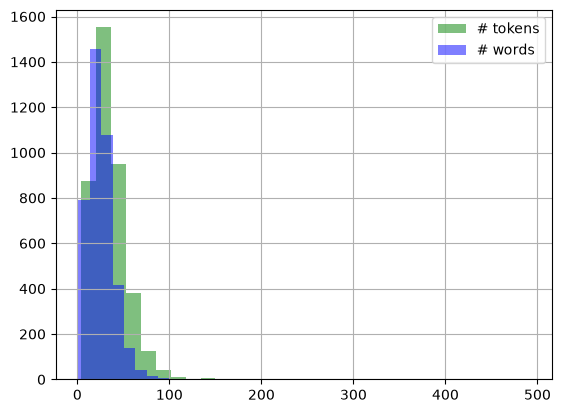

In [13]:
df['n_toks'].hist(color = "green", alpha=0.5, bins=30)
df['n_words'].hist(color = "blue", alpha=0.5, bins=30)
plt.legend(['# tokens', '# words'])
plt.show()

In [14]:
# compute share of sentences that will be truncated
(df['n_toks'] > classifier.tokenizer.model_max_length).mean()

np.float64(0.0)

## Apply classifier to the texts

Let's draw a balanced sample for comparing performance across housing and
non-housing sentences. This sample is useful for teaching precision and recall,
but it does not represent the prevalence of housing sentences in the corpus.


In [21]:
df["cap_housing_topic"] = df["cap_topic"].eq(14)
# NOTE: in the given data, Housing is CAP topic 14

sample_df = (
    df.groupby("cap_housing_topic", group_keys=False)
    .sample(50, random_state=42)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

In [22]:
preds = classifier(sample_df.text.tolist(), batch_size=32)

In [27]:
sample_df["pred_label"] = [p['label'] for p in preds]
sample_df["pred_housing"] = sample_df["pred_label"] == "Housing"
# NOTE: if you use the manifestoproject model, there is no Housing category

In [28]:
sample_df.value_counts(["cap_housing_topic", "pred_housing"])

cap_housing_topic  pred_housing
False              False           50
True               False           35
                   True            15
Name: count, dtype: int64

## Compute eval metrics

In [29]:
from sklearn.metrics import classification_report

y_true = sample_df["cap_housing_topic"]
y_pred = sample_df["pred_housing"]

report = classification_report(
    y_true,
    y_pred,
    target_names=["not housing", "housing"],
    zero_division=0,
)
print(report)

              precision    recall  f1-score   support

 not housing       0.59      1.00      0.74        50
     housing       1.00      0.30      0.46        50

    accuracy                           0.65       100
   macro avg       0.79      0.65      0.60       100
weighted avg       0.79      0.65      0.60       100



Because the checkpoint was trained on CAP-coded parliamentary text, these results
are best treated as an illustration of the inference and evaluation workflow unless
the provenance of the checkpoint's training data establishes that these sentences
were held out.